In [33]:
import pandas as pd
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

In [23]:
# 1. Call the function to fetch the data object
housing = fetch_california_housing(as_frame = True) # as_frame for direct DataFrame
X = housing.data
Y = housing.target


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state= 456 # last 3 id digits
)

In [27]:
scale = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both sets
X_train_scaled = pd.DataFrame(
    scale.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scale.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [28]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
12312,-0.501896,-1.639494,0.425025,0.551459,-0.844958,-0.068140,-0.945847,1.541723
608,-0.778449,0.669451,-0.507230,-0.224578,-0.969939,-0.132041,0.961313,-1.260291
4738,0.548836,1.624877,-0.657978,-0.673476,-0.844084,-0.055380,-0.739667,0.591039
11270,-0.175596,-1.082163,-0.357368,-0.093735,0.765817,-0.056876,-0.866186,0.786180
19977,-0.779564,-0.684069,5.268098,8.477910,-0.669285,-0.037435,0.089736,0.430924


In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Define the Neural Network Architecture
baseline_model = Sequential([
    # First hidden layer with a non-linear activation function (ReLU)
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Second hidden layer, also using ReLU
    Dense(32, activation='relu'),
    
    # Output layer
    # A single node with no activation function is used for regression
    Dense(1)
])

# 2. Compile the Model
# We formulate the problem as a regression task and use mean squared error as the loss function
baseline_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Display the architecture 
baseline_model.summary()

# 3. Train the Baseline Model
print("Training the baseline model...")
history_baseline = baseline_model.fit(
    X_train_scaled, 
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2, # Uses 20% of the training data to monitor validation loss
    verbose=1
)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Training the baseline model...
Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5269 - val_loss: 0.3763
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.3842 - val_loss: 0.3430
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3540 - val_loss: 0.3192
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3477 - val_loss: 0.3370
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3348 - val_loss: 0.3287
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3339 - val_loss: 0.3522
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3084 - val_loss: 0.3284
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3128 - val_loss: 0.3074
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3088 - val_loss: 0.3205
Epoch 10/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3098 - val_loss: 0.3856
Epoch 11/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3016 - val_loss: 0.3290
Epoch 12/50
387/387

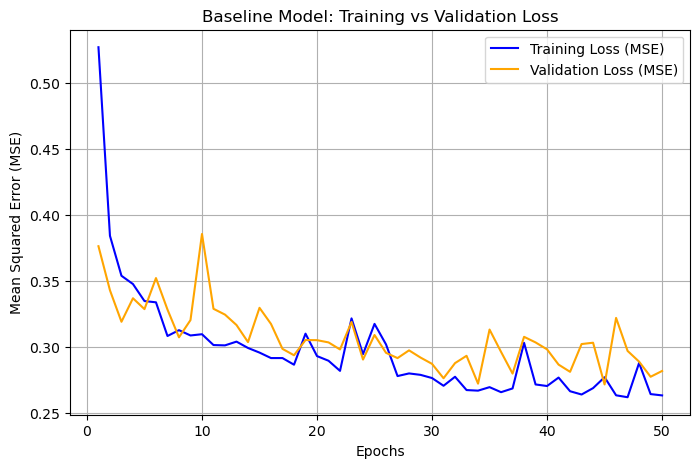

In [36]:
train_loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss (MSE)', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss (MSE)', color='orange')

# Add labels and title
plt.title('Baseline Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()